This notebook establishes a pipeline for thermal energy demand forecasting. It starts with data preparation that enforces an hourly frequency and identifies a 15.78% missing data rate. Preprocessing evaluates two imputation strategies—Historical Average and Linear Interpolation—and generates cyclical temporal encodings. Performance is benchmarked against Daily Naive, Weekly Naive, and Combined Seasonal models. Advanced modeling includes XGBoost with historical lags, SARIMA, and LSTM networks.

In [21]:
import pandas as pd
import numpy as np
from typing import Tuple, Dict, Optional
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Configuration
FILE_PATH = '/RawData_MeasuredHeadDemand.csv'
TIME_COL = 'Time Point'
TARGET_COL = 'Measured Heat Demand[W]'

In [22]:
class DataCleaner:
    @staticmethod
    def clean_and_validate(df: pd.DataFrame, time_col: str, target_col: str) -> pd.DataFrame:
        df = df.copy()
        if time_col in df.columns:
            df[time_col] = pd.to_datetime(df[time_col])
            df = df.set_index(time_col)
        df = df.loc[~df.index.duplicated(keep='first')]
        df = df.asfreq('h')
        return df

class TimeSeriesImputer:
    def __init__(self, strategy: str = 'historical_avg'):
        valid_strategies = ['historical_avg', 'linear_interpolation']
        if strategy not in valid_strategies:
            raise ValueError(f"Strategy must be one of {valid_strategies}")
        self.strategy = strategy
        self.hourly_means_: Optional[Dict[int, float]] = None

    def fit(self, X: pd.DataFrame, target_col: str):
        if self.strategy == 'historical_avg':
            self.hourly_means_ = X.groupby(X.index.hour)[target_col].mean().to_dict()
        return self

    def transform(self, X: pd.DataFrame, target_col: str) -> pd.DataFrame:
        X_out = X.copy()
        if self.strategy == 'linear_interpolation':
            X_out[target_col] = X_out[target_col].interpolate(method='linear')
        elif self.strategy == 'historical_avg':
            if self.hourly_means_ is None:
                raise RuntimeError("Imputer must be fitted first.")
            mapped_means_index = X_out.index.hour.map(self.hourly_means_)
            mapped_means_series = pd.Series(mapped_means_index, index=X_out.index)
            X_out[target_col] = X_out[target_col].fillna(mapped_means_series)

        X_out[target_col] = X_out[target_col].ffill().bfill()
        return X_out

class FeatureEngineer:
    @staticmethod
    def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['hour'] = df.index.hour
        df['day_of_week'] = df.index.dayofweek
        df['month'] = df.index.month
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
        return df

class DataSplitter:
    @staticmethod
    def time_based_split(df: pd.DataFrame, test_months: int = 3) -> Tuple[pd.DataFrame, pd.DataFrame]:
        end_date = df.index.max()
        split_date = end_date - pd.DateOffset(months=test_months)
        train_df = df[df.index < split_date].copy()
        test_df = df[df.index >= split_date].copy()
        return train_df, test_df

class BaselineForecasters:
    def __init__(self, y_train: pd.Series):
        self.train_mean = y_train.mean()

    def _safe_shift(self, series: pd.Series, periods: int) -> pd.Series:
        shifted = series.shift(periods)
        shifted = shifted.ffill()
        shifted = shifted.fillna(self.train_mean)
        return shifted

    def predict_daily_naive(self, full_series: pd.Series) -> pd.Series:
        r"""Forecast: \hat{y}_t = y_{t-24}"""
        return self._safe_shift(full_series, periods=24)

    def predict_weekly_naive(self, full_series: pd.Series) -> pd.Series:
        r"""Forecast: \hat{y}_t = y_{t-168}"""
        return self._safe_shift(full_series, periods=168)

    def predict_combined_seasonal(self, full_series: pd.Series) -> pd.Series:
        r"""Forecast: \hat{y}_t = \frac{1}{2}(y_{t-24} + y_{t-168})"""
        daily_forecast = self.predict_daily_naive(full_series)
        weekly_forecast = self.predict_weekly_naive(full_series)
        return (daily_forecast + weekly_forecast) / 2

In [23]:
def calculate_metrics(actual, pred) -> dict:
    """Calculates standard forecasting metrics."""
    return {
        'RMSE': np.sqrt(mean_squared_error(actual, pred)),
        'MAE': mean_absolute_error(actual, pred),
        'MAPE (%)': mean_absolute_percentage_error(actual, pred) * 100
    }

def run_pipeline_and_evaluate(strategy: str, df: pd.DataFrame, time_col: str, target_col: str) -> list:
    """Runs the full pipeline for a given imputation strategy and returns metrics."""
    # 1. Clean Data
    df_cleaned = DataCleaner.clean_and_validate(df, time_col=time_col, target_col=target_col)

    # 2. Split Data
    train_df, test_df = DataSplitter.time_based_split(df_cleaned, test_months=3)

    # 3. Impute Data
    imputer = TimeSeriesImputer(strategy=strategy)
    train_df = imputer.fit(train_df, target_col=target_col).transform(train_df, target_col=target_col)
    test_df = imputer.transform(test_df, target_col=target_col)

    # 4. Generate Features (needed for ML later, good to include in pipeline)
    train_df = FeatureEngineer.create_temporal_features(train_df)
    test_df = FeatureEngineer.create_temporal_features(test_df)

    # 5. Initialize Baselines & Forecast
    baselines = BaselineForecasters(y_train=train_df[target_col])
    full_target_series = pd.concat([train_df[target_col], test_df[target_col]])

    daily_preds = baselines.predict_daily_naive(full_target_series).loc[test_df.index]
    weekly_preds = baselines.predict_weekly_naive(full_target_series).loc[test_df.index]
    combined_preds = baselines.predict_combined_seasonal(full_target_series).loc[test_df.index]

    # 6. Collect Metrics
    test_actuals = test_df[target_col]
    return [
        {'Strategy': strategy, 'Model': 'Seasonal Naive (Daily)', **calculate_metrics(test_actuals, daily_preds)},
        {'Strategy': strategy, 'Model': 'Seasonal Naive (Weekly)', **calculate_metrics(test_actuals, weekly_preds)},
        {'Strategy': strategy, 'Model': 'Combined Seasonal', **calculate_metrics(test_actuals, combined_preds)}
    ]

In [24]:
# Load the raw data once
print("Loading data...")
raw_df = pd.read_csv(FILE_PATH)
raw_df[TIME_COL] = pd.to_datetime(raw_df[TIME_COL], utc=True)

# Run the evaluation loop
strategies = ['historical_avg', 'linear_interpolation']
all_results = []

for strat in strategies:
    strat_results = run_pipeline_and_evaluate(strat, raw_df, TIME_COL, TARGET_COL)
    all_results.extend(strat_results)

# Display a beautiful summary table
results_df = pd.DataFrame(all_results)
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f"{x:,.0f}")
results_df['MAE'] = results_df['MAE'].apply(lambda x: f"{x:,.0f}")
results_df['MAPE (%)'] = results_df['MAPE (%)'].apply(lambda x: f"{x:.2f}%")

print("\n" + "="*80)
print("BASELINE FORECASTING PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

Loading data...

BASELINE FORECASTING PERFORMANCE COMPARISON
            Strategy                   Model      RMSE       MAE MAPE (%)
      historical_avg  Seasonal Naive (Daily) 2,151,582 1,277,222   13.96%
      historical_avg Seasonal Naive (Weekly) 3,327,804 2,375,743   28.60%
      historical_avg       Combined Seasonal 2,232,318 1,560,708   18.33%
linear_interpolation  Seasonal Naive (Daily) 2,127,707 1,264,493   13.76%
linear_interpolation Seasonal Naive (Weekly) 3,324,672 2,373,108   28.51%
linear_interpolation       Combined Seasonal 2,221,147 1,553,996   18.21%


XGBoost


Engineering lag features...
Features ready! X_train shape: (15215, 9)
Initializing and training XGBoost model...

XGBOOST MODEL PERFORMANCE (TEST SET)
RMSE: 2,232,416 | MAE: 1,539,253 | MAPE: 17.28%


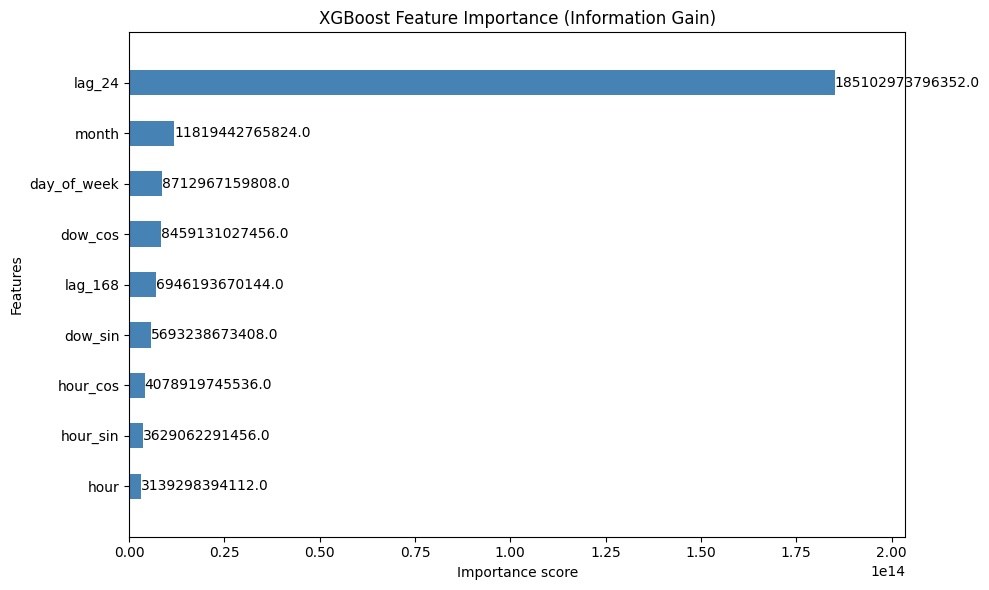

In [28]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Use the exact target column from our pipeline
target_col = 'Measured Heat Demand[W]'


# ==========================================
# 1. Prepare Features (X) and Target (y) WITH LAGS
# ==========================================
print("Engineering lag features...")

# Temporarily stitch the datasets together to let lags cross the split boundary
full_df = pd.concat([train_df, test_df])

# Create the past-looking features
full_df['lag_24'] = full_df[target_col].shift(24)
full_df['lag_168'] = full_df[target_col].shift(168)

# The first 168 hours of the entire dataset now have NaNs because there is no history before index 0.
# We must drop these rows so XGBoost doesn't crash, which slightly shrinks our training set.
full_df = full_df.dropna()

# Re-split exactly where we did before
split_date = test_df.index.min()

X_train = full_df[full_df.index < split_date].drop(columns=[target_col])
y_train = full_df[full_df.index < split_date][target_col]

X_test = full_df[full_df.index >= split_date].drop(columns=[target_col])
y_test = full_df[full_df.index >= split_date][target_col]

print(f"Features ready! X_train shape: {X_train.shape}")

# 2. Initialize and Train the XGBoost Model
print("Initializing and training XGBoost model...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,                  # Standard depth for tabular data
    objective='reg:squarederror', # Standard objective for regression
    random_state=42,              # Ensures reproducibility
    n_jobs=-1                     # Uses all CPU cores for faster training
)

xgb_model.fit(X_train, y_train)

# 3. Generate Predictions on the Test Set
xgb_preds = xgb_model.predict(X_test)

# 4. Evaluate the Model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds) * 100

print("\n" + "="*60)
print("XGBOOST MODEL PERFORMANCE (TEST SET)")
print("="*60)
print(f"RMSE: {xgb_rmse:,.0f} | MAE: {xgb_mae:,.0f} | MAPE: {xgb_mape:.2f}%")
print("="*60)

# 5. Plot Feature Importance
# Using 'gain' shows the average improvement in accuracy brought by a feature
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    xgb_model,
    importance_type='gain',
    max_num_features=10,
    height=0.5,
    ax=plt.gca(),
    color='steelblue'
)
plt.title('XGBoost Feature Importance (Information Gain)')
plt.grid(False)
plt.tight_layout()
plt.show()

SARIMA

In [30]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.7 MB/s eta 0:00:00


In [31]:
import pmdarima as pm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

print("--- Step 1: Checking Stationarity ---")
# 1. Check Stationarity using the Augmented Dickey-Fuller (ADF) test
# Null Hypothesis (H0): The series has a unit root (is non-stationary)
adf_result = adfuller(y_train.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Result: Data is stationary (Reject H0). Differencing 'd' may be 0.")
else:
    print("Result: Data is non-stationary (Fail to reject H0). Differencing 'd' is required.")

# 2. Prepare a Training Subset to keep computation times realistic
# SARIMA with m=24 on 15k rows can take hours. We use the last 4 weeks (672 hours) of training data.
print("\n--- Step 2: Fitting SARIMA Model ---")
subset_hours = 24 * 28
y_train_subset = y_train.iloc[-subset_hours:]
print(f"Training on the most recent {subset_hours} hours to optimize computation time...")

# 3. Fit Auto-ARIMA
# We limit the search space (max_p, max_q) and enforce stepwise to prevent endless loops
sarima_model = pm.auto_arima(
    y_train_subset,
    seasonal=True,
    m=24,                      # Daily seasonality for hourly data
    stepwise=True,             # Smart search algorithm (much faster)
    trace=True,                # Prints the search progress
    max_p=2, max_q=2,          # Limit non-seasonal AR/MA terms
    max_P=1, max_Q=1,          # Limit seasonal AR/MA terms
    error_action='ignore',
    suppress_warnings=True,
    random_state=42
)

print("\nBest SARIMA Model Found:")
print(sarima_model.summary())

# 4. Generate Forecasts
print("\n--- Step 3: Generating Forecasts ---")
# Forecast exactly the number of steps in the test set
forecast_steps = len(y_test)
sarima_preds = sarima_model.predict(n_periods=forecast_steps)

# Align the index of predictions with the test set for fair comparison
sarima_preds.index = y_test.index

# 5. Evaluate the Results
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_preds))
sarima_mae = mean_absolute_error(y_test, sarima_preds)
sarima_mape = mean_absolute_percentage_error(y_test, sarima_preds) * 100

print("\n" + "="*60)
print("SARIMA MODEL PERFORMANCE (TEST SET)")
print("="*60)
print(f"RMSE: {sarima_rmse:,.0f} | MAE: {sarima_mae:,.0f} | MAPE: {sarima_mape:.2f}%")
print("="*60)

--- Step 1: Checking Stationarity ---
ADF Statistic: -3.7485
p-value: 0.0035
Result: Data is stationary (Reject H0). Differencing 'd' may be 0.

--- Step 2: Fitting SARIMA Model ---
Training on the most recent 672 hours to optimize computation time...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=20709.604, Time=12.74 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=20981.590, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=20771.913, Time=2.59 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=20765.117, Time=2.32 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=20979.602, Time=0.11 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=20724.696, Time=4.53 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=20707.613, Time=2.79 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=20804.444, Time=0.50 sec
 ARIMA(1,1,2)(1,0,0)[24] intercept   : AIC=20707.771, Time=1.86 sec
 ARIMA(2,1,1)(1,0,0)[24] intercept   : AIC=20716.616, Time=3.23 sec
 ARIMA(1,1,1)(1,0,0)[24]

LSTM

In [32]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("--- Step 1: Preparing Data for LSTM ---")

# Define our look-back window (1 week of hourly data)
TIME_STEPS = 168

# 1. Separate features and target
X_train_df = train_df.drop(columns=[target_col])
y_train_df = train_df[[target_col]]

# To predict the beginning of the test set, we must give it the end of the training set
test_df_extended = pd.concat([train_df.iloc[-TIME_STEPS:], test_df])
X_test_ext = test_df_extended.drop(columns=[target_col])
y_test_ext = test_df_extended[[target_col]]

# 2. Scale the data (Fit ONLY on training data to prevent leakage)
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = x_scaler.fit_transform(X_train_df)
y_train_scaled = y_scaler.fit_transform(y_train_df)

X_test_scaled = x_scaler.transform(X_test_ext)
y_test_scaled = y_scaler.transform(y_test_ext)

# 3. Create sliding window sequences
def create_sequences(X, y, time_steps):
    """Slides a window over the data to create 3D tensors: (samples, time_steps, features)"""
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"Train Tensor Shape: {X_train_seq.shape}") # Should be (samples, 168, features)
print(f"Test Tensor Shape: {X_test_seq.shape}")   # Should exactly match len(test_df)

print("\n--- Step 2: Building & Training LSTM ---")

# 4. Define the LSTM Architecture
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2), # Prevents overfitting by randomly turning off 20% of neurons
    Dense(32, activation='relu'),
    Dense(1)      # Output layer (predicting 1 value)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# 5. Train the model with Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,               # Stop if validation loss doesn't improve for 5 epochs
    restore_best_weights=True # Keep the best model, not the last model
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.1,     # Use last 10% of training data to monitor for overfitting
    callbacks=[early_stop],
    verbose=1
)

print("\n--- Step 3: Evaluation ---")

# 6. Generate predictions
lstm_preds_scaled = model.predict(X_test_seq)

# 7. Inverse transform to get back to original scale (Watts)
lstm_preds = y_scaler.inverse_transform(lstm_preds_scaled).flatten()
y_test_actual = y_scaler.inverse_transform(y_test_seq).flatten()

# 8. Calculate Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
lstm_mae = mean_absolute_error(y_test_actual, lstm_preds)
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_preds) * 100

print("\n" + "="*60)
print("LSTM MODEL PERFORMANCE (TEST SET)")
print("="*60)
print(f"RMSE: {lstm_rmse:,.0f} | MAE: {lstm_mae:,.0f} | MAPE: {lstm_mape:.2f}%")
print("="*60)

--- Step 1: Preparing Data for LSTM ---
Train Tensor Shape: (15215, 168, 7)
Test Tensor Shape: (2161, 168, 7)

--- Step 2: Building & Training LSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - loss: 0.0084 - val_loss: 0.0164
Epoch 2/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0046 - val_loss: 0.0173
Epoch 3/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.0041 - val_loss: 0.0170
Epoch 4/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.0041 - val_loss: 0.0160
Epoch 5/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - loss: 0.0039 - val_loss: 0.0150
Epoch 6/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - loss: 0.0039 - val_loss: 0.0169
Epoch 7/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - loss: 0.0037 - val_loss: 0.0155
Epoch 8/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.0037 - val_loss: 0.0170
Epoch 9/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - loss: 0.0037 - val_loss: 0.0157
Epoch 10/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.0036 - val_loss: 0.0178

--- Step 3: Evaluation ---
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step

LSTM MODEL PERFORMANCE (TEST SET)
RMSE: 2,411,263 